# Complicated 100-Point → 100-Point Trace Mapping

Written by ChatGPT with help from Scott Feister on 2026-06-16.

This notebook gives you a complete toy workflow:

1. Define a deliberately complicated synthetic function `x -> y`
2. Add optional synthetic noise
3. Generate paired training data
4. Run sanity-test functions
5. Train simple models to learn `X -> Y`
6. Plot predictions against truth

The point is not to build the world's fanciest model. The point is to have a fake but nontrivial 100-point signal transformation that you can use as a playground.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## 1. Define the synthetic 100 → 100 function

This function is intentionally a little ugly. It includes local smoothing, derivatives, nonlinear response, global input statistics, position-dependent gain, saturation, baseline structure, and optional random noise.

In [2]:
def complicated_trace_map(x, noise_std=0.0, rng=None):
    '''
    Map one 100-point 1D trace to another 100-point 1D trace.

    Parameters
    ----------
    x : array-like, shape (100,)
        Input trace.

    noise_std : float
        Standard deviation of additive Gaussian output noise.
        Use 0.0 for no noise, 0.03 for moderate noise.

    rng : numpy.random.Generator or None
        Random number generator. Pass one in for reproducible noise.

    Returns
    -------
    y : numpy.ndarray, shape (100,)
        Output trace.
    '''

    x = np.asarray(x, dtype=float)

    if x.shape != (100,):
        raise ValueError(f"Expected x with shape (100,), got {x.shape}")

    if rng is None:
        rng = np.random.default_rng()

    t = np.linspace(0.0, 1.0, 100)

    # Local smoothing and derivative-like kernels.
    kernel_1 = np.array([0.05, 0.15, 0.60, 0.15, 0.05])
    kernel_2 = np.array([-0.08, -0.04, 0.00, 0.04, 0.08])

    smooth = np.convolve(x, kernel_1, mode="same")
    slope_like = np.convolve(x, kernel_2, mode="same")

    # Global features of the input trace.
    mean_x = np.mean(x)
    std_x = np.std(x)
    energy_x = np.mean(x**2)
    left_right_balance = np.mean(x[:50]) - np.mean(x[50:])

    # Position-dependent gain.
    gain = (
        1.0
        + 0.25 * np.sin(2.0 * np.pi * t)
        + 0.10 * np.cos(6.0 * np.pi * t)
    )

    # Input-dependent integer shift.
    shift_amount = int(np.round(3.0 * np.tanh(left_right_balance)))
    shifted = np.roll(smooth, shift_amount)

    # Nonlinear local response.
    nonlinear_local = (
        0.85 * np.tanh(1.2 * shifted)
        + 0.20 * shifted**2
        - 0.05 * shifted**3
        + 0.35 * slope_like
    )

    # Whole-trace global modulation.
    global_modulation = (
        0.15 * mean_x
        + 0.10 * std_x * np.sin(4.0 * np.pi * t)
        + 0.08 * energy_x * np.cos(2.0 * np.pi * t)
    )

    # Weak input-dependent ripple.
    phase = 2.0 * np.pi * np.tanh(mean_x + left_right_balance)
    ripple = 0.04 * np.sin(18.0 * np.pi * t + phase)

    # Combine terms.
    y = gain * nonlinear_local + global_modulation + ripple

    # Saturating output-side response.
    y = 1.5 * np.tanh(y / 1.5)

    # Deterministic baseline shape.
    baseline = 0.08 * (t - 0.5) + 0.05 * np.exp(-((t - 0.75) / 0.12) ** 2)
    y = y + baseline

    # Synthetic measurement noise.
    if noise_std > 0.0:
        y = y + rng.normal(loc=0.0, scale=noise_std, size=100)

    return y

## 2. Input trace generator

This makes smooth-ish random 100-point inputs.

In [3]:
def generate_random_input_trace(rng=None):
    '''
    Generate one smooth-ish random input trace with shape (100,).
    '''

    if rng is None:
        rng = np.random.default_rng()

    t = np.linspace(0.0, 1.0, 100)

    x = (
        rng.normal(0, 0.15, size=100)
        + rng.normal() * np.sin(2 * np.pi * t)
        + rng.normal() * np.sin(4 * np.pi * t)
        + rng.normal() * np.cos(6 * np.pi * t)
        + 0.5 * rng.normal() * np.exp(-((t - rng.uniform(0.2, 0.8)) / rng.uniform(0.05, 0.18)) ** 2)
    )

    # Smooth slightly.
    x = np.convolve(x, np.ones(5) / 5, mode="same")

    return x


def generate_dataset(n_examples=1000, noise_std=0.03, seed=0):
    '''
    Generate paired X, Y arrays.

    Returns
    -------
    X : np.ndarray, shape (n_examples, 100)
    Y : np.ndarray, shape (n_examples, 100)
    '''

    rng = np.random.default_rng(seed)

    X = np.zeros((n_examples, 100))
    Y = np.zeros((n_examples, 100))

    for i in range(n_examples):
        x = generate_random_input_trace(rng)
        y = complicated_trace_map(x, noise_std=noise_std, rng=rng)

        X[i] = x
        Y[i] = y

    return X, Y

## 3. Test functions / sanity checks

These are not formal unit tests with `pytest`. They are simple notebook checks that catch common mistakes.

In [4]:
def test_output_shape():
    rng = np.random.default_rng(1)
    x = generate_random_input_trace(rng)
    y = complicated_trace_map(x, noise_std=0.0, rng=rng)

    assert y.shape == (100,), f"Expected output shape (100,), got {y.shape}"


def test_wrong_input_shape_fails():
    bad_x = np.zeros(99)

    try:
        complicated_trace_map(bad_x)
    except ValueError:
        return

    raise AssertionError("Expected ValueError for input shape other than (100,)")


def test_deterministic_without_noise():
    rng = np.random.default_rng(2)
    x = generate_random_input_trace(rng)

    y1 = complicated_trace_map(x, noise_std=0.0, rng=np.random.default_rng(10))
    y2 = complicated_trace_map(x, noise_std=0.0, rng=np.random.default_rng(999))

    assert np.allclose(y1, y2), "Noiseless output should be deterministic"


def test_noise_changes_output():
    rng = np.random.default_rng(3)
    x = generate_random_input_trace(rng)

    y_clean = complicated_trace_map(x, noise_std=0.0, rng=np.random.default_rng(10))
    y_noisy = complicated_trace_map(x, noise_std=0.05, rng=np.random.default_rng(10))

    assert not np.allclose(y_clean, y_noisy), "Noisy output should differ from clean output"


def test_dataset_shapes():
    X, Y = generate_dataset(n_examples=12, noise_std=0.03, seed=4)

    assert X.shape == (12, 100), f"Expected X shape (12, 100), got {X.shape}"
    assert Y.shape == (12, 100), f"Expected Y shape (12, 100), got {Y.shape}"


def run_all_tests():
    test_output_shape()
    test_wrong_input_shape_fails()
    test_deterministic_without_noise()
    test_noise_changes_output()
    test_dataset_shapes()

    print("All sanity tests passed.")


run_all_tests()

All sanity tests passed.


## 4. Visualize the synthetic mapping

One input trace, one clean output, and one noisy output.

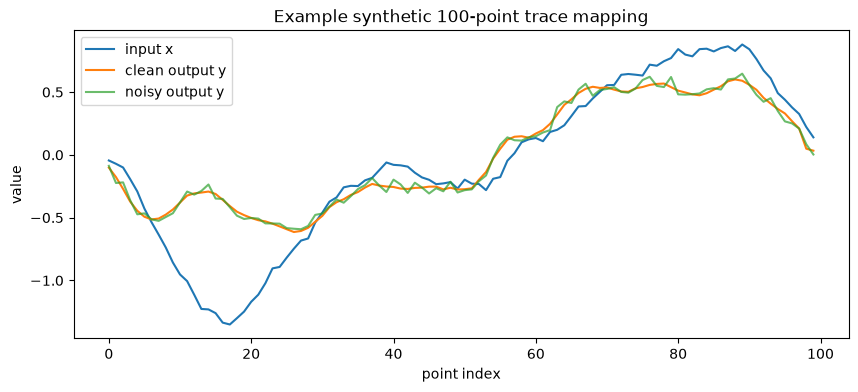

In [5]:
rng = np.random.default_rng(5)

x = generate_random_input_trace(rng)
y_clean = complicated_trace_map(x, noise_std=0.0, rng=rng)
y_noisy = complicated_trace_map(x, noise_std=0.03, rng=rng)

plt.figure(figsize=(10, 4))
plt.plot(x, label="input x")
plt.plot(y_clean, label="clean output y")
plt.plot(y_noisy, label="noisy output y", alpha=0.7)
plt.xlabel("point index")
plt.ylabel("value")
plt.legend()
plt.title("Example synthetic 100-point trace mapping")
plt.show()

## 5. Generate a dataset

Increase `n_examples` if you want the MLP to do better.

In [6]:
X, Y = generate_dataset(
    n_examples=2000,
    noise_std=0.03,
    seed=0,
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

X shape: (2000, 100)
Y shape: (2000, 100)
Training examples: 1600
Testing examples: 400


## 6. Train a simple Ridge model

This is the boring baseline. It is useful because if this works, you do not need anything fancier.

In [7]:
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

ridge_model.fit(X_train, Y_train)

Y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(Y_test, Y_pred_ridge)
ridge_rmse = mean_squared_error(Y_test, Y_pred_ridge) ** 0.5
ridge_r2 = r2_score(Y_test, Y_pred_ridge)

print("Ridge MAE: ", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R^2: ", ridge_r2)

Ridge MAE:  0.3303995139007108
Ridge RMSE: 0.4406614885298511
Ridge R^2:  0.31371584622068976


## 7. Train a slightly fancier MLP model

This is still intentionally basic. It is the first nonlinear fallback.

In [8]:
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(128, 128),
        activation="relu",
        max_iter=2000,
        early_stopping=True,
        random_state=0,
    )
)

mlp_model.fit(X_train, Y_train)

Y_pred_mlp = mlp_model.predict(X_test)

mlp_mae = mean_absolute_error(Y_test, Y_pred_mlp)
mlp_rmse = mean_squared_error(Y_test, Y_pred_mlp) ** 0.5
mlp_r2 = r2_score(Y_test, Y_pred_mlp)

print("MLP MAE: ", mlp_mae)
print("MLP RMSE:", mlp_rmse)
print("MLP R^2: ", mlp_r2)

MLP MAE:  0.07412341016108864
MLP RMSE: 0.10650259981862994
MLP R^2:  0.9579279154780249


## 8. Plot predictions

The plot matters more than the scalar score here.

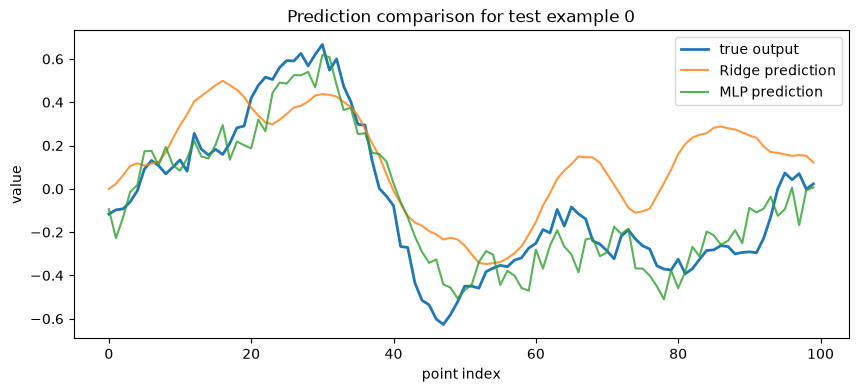

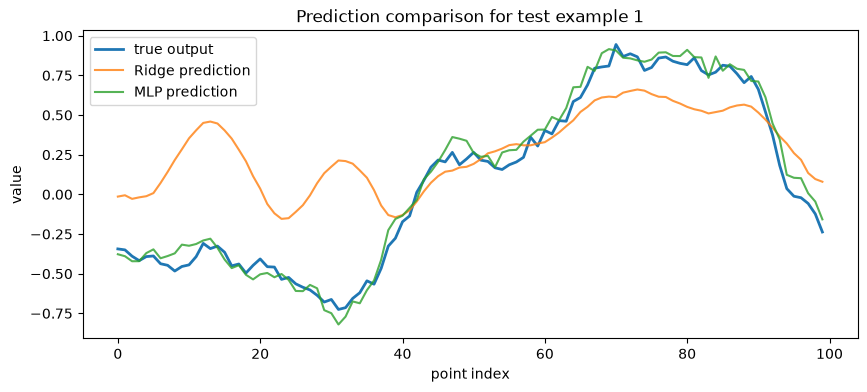

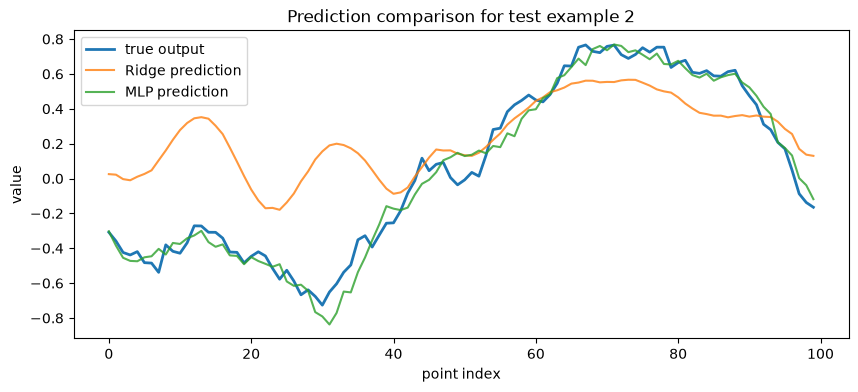

In [9]:
def plot_prediction(example_index=0):
    plt.figure(figsize=(10, 4))

    plt.plot(Y_test[example_index], label="true output", linewidth=2)
    plt.plot(Y_pred_ridge[example_index], label="Ridge prediction", alpha=0.8)
    plt.plot(Y_pred_mlp[example_index], label="MLP prediction", alpha=0.8)

    plt.xlabel("point index")
    plt.ylabel("value")
    plt.legend()
    plt.title(f"Prediction comparison for test example {example_index}")
    plt.show()


plot_prediction(0)
plot_prediction(1)
plot_prediction(2)

## 9. Train the reverse direction: Y → X

This is the same idea, just reversed.

In [10]:
reverse_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(128, 128),
        activation="relu",
        max_iter=2000,
        early_stopping=True,
        random_state=1,
    )
)

reverse_model.fit(Y_train, X_train)

X_pred = reverse_model.predict(Y_test)

reverse_mae = mean_absolute_error(X_test, X_pred)
reverse_rmse = mean_squared_error(X_test, X_pred) ** 0.5
reverse_r2 = r2_score(X_test, X_pred)

print("Reverse Y -> X MAE: ", reverse_mae)
print("Reverse Y -> X RMSE:", reverse_rmse)
print("Reverse Y -> X R^2: ", reverse_r2)

Reverse Y -> X MAE:  0.1413944084824247
Reverse Y -> X RMSE: 0.295847273779357
Reverse Y -> X R^2:  0.9380599272696347


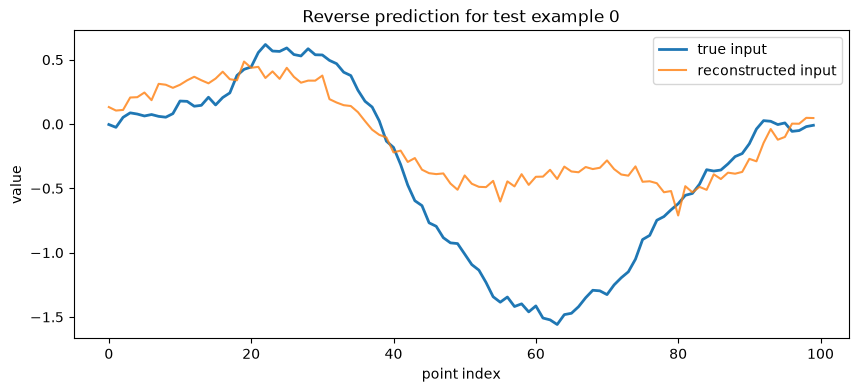

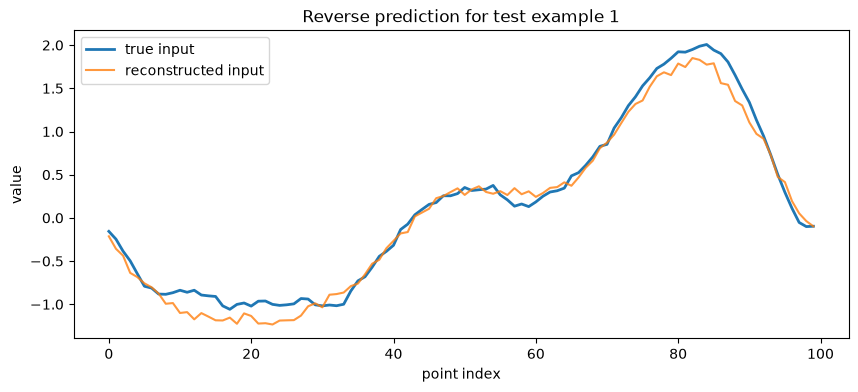

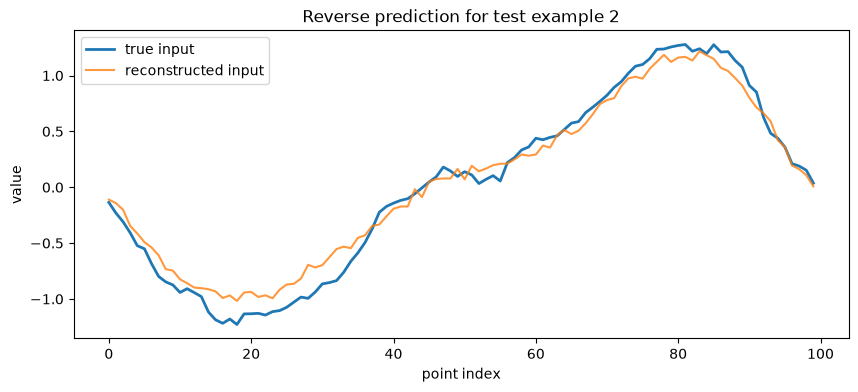

In [11]:
def plot_reverse_prediction(example_index=0):
    plt.figure(figsize=(10, 4))

    plt.plot(X_test[example_index], label="true input", linewidth=2)
    plt.plot(X_pred[example_index], label="reconstructed input", alpha=0.8)

    plt.xlabel("point index")
    plt.ylabel("value")
    plt.legend()
    plt.title(f"Reverse prediction for test example {example_index}")
    plt.show()


plot_reverse_prediction(0)
plot_reverse_prediction(1)
plot_reverse_prediction(2)

## 10. Save the data and trained models

Uncomment this cell if you want files written next to the notebook.

In [ ]:
# import joblib

# np.save("X.npy", X)
# np.save("Y.npy", Y)

# joblib.dump(ridge_model, "ridge_model_xy.joblib")
# joblib.dump(mlp_model, "mlp_model_xy.joblib")
# joblib.dump(reverse_model, "mlp_model_yx.joblib")

In [12]:
X, Y = generate_dataset(
    n_examples=2000,
    noise_std=0.03,
    seed=0,
)


In [14]:
X.shape

(2000, 100)

In [15]:
Y.shape

(2000, 100)